# Homework A2

**Question:** Suppose the globe tossing data (Chapter 2) had turned out to be 3 water and 11 land. Construct the posterior distribution. Then using the posterior distribution, compute the posterior predictive distribution for the next 5 tosses of the same globe.

## 1. Construct the posterior distribution

We use grid approximation to compute the posterior distribution of $p$ (the proportion of water), assuming a uniform prior over $p$.

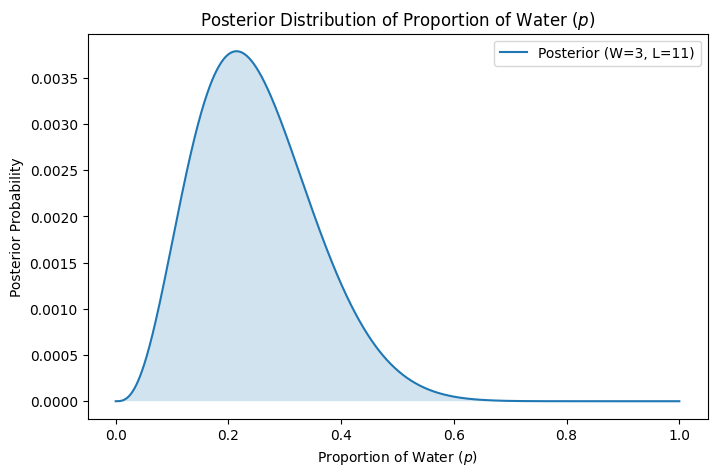

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Data
W = 3
L = 11
N = W + L

# Grid approximation
p_grid = np.linspace(0, 1, 1000)

# Uniform prior
prior = np.ones(1000)

# Binomial likelihood
likelihood = stats.binom.pmf(W, N, p_grid)

# Unstandardized posterior
unstd_posterior = likelihood * prior

# Standardized posterior
posterior = unstd_posterior / np.sum(unstd_posterior)

# Plot the posterior distribution
plt.figure(figsize=(8, 5))
plt.plot(p_grid, posterior, label="Posterior (W=3, L=11)")
plt.title("Posterior Distribution of Proportion of Water ($p$)")
plt.xlabel("Proportion of Water ($p$)")
plt.ylabel("Posterior Probability")
plt.fill_between(p_grid, posterior, alpha=0.2)
plt.legend()
plt.show()

## 2. Compute the posterior predictive distribution for the next 5 tosses

To generate the posterior predictive distribution, we can sample parameter values $p$ from the posterior distribution and then simulate the next 5 tosses (Binomial distribution) for each sampled $p$.

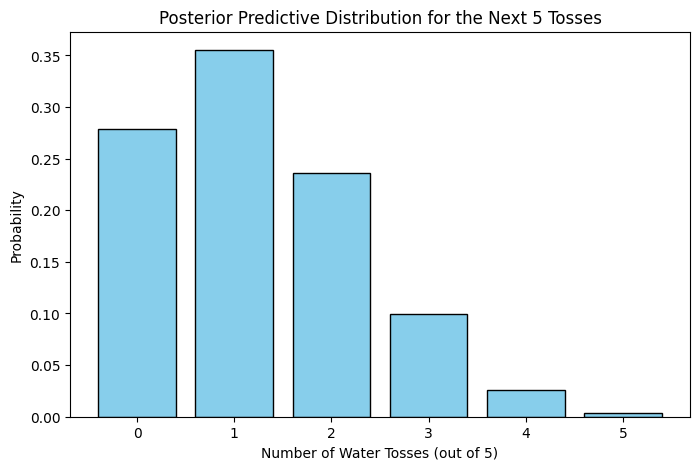

In [2]:
# Set a random seed for reproducibility
np.random.seed(42)

# Sample from the posterior distribution
samples = np.random.choice(p_grid, p=posterior, size=10000, replace=True)

# Simulate the next 5 tosses (Binomial distribution for each sampled p)
next_tosses = 5
w_pred = stats.binom.rvs(n=next_tosses, p=samples)

# Plot the posterior predictive distribution
plt.figure(figsize=(8, 5))
# Count frequencies of 0 to 5 water tosses
w_counts = np.bincount(w_pred, minlength=next_tosses+1)
plt.bar(range(next_tosses + 1), w_counts / np.sum(w_counts), color="skyblue", edgecolor="black")
plt.title("Posterior Predictive Distribution for the Next 5 Tosses")
plt.xlabel("Number of Water Tosses (out of 5)")
plt.ylabel("Probability")
plt.xticks(range(next_tosses + 1))
plt.show()

Alternatively, we can compute it exactly using the Beta-Binomial distribution, since a Binomial likelihood with a Uniform(0,1) prior (which is Beta(1,1)) results in a Beta(1+W, 1+L) posterior.

Number of water tosses | Exact Probability
---------------------------------------------
0                      | 0.2817
1                      | 0.3522
2                      | 0.2348
3                      | 0.1006
4                      | 0.0271
5                      | 0.0036


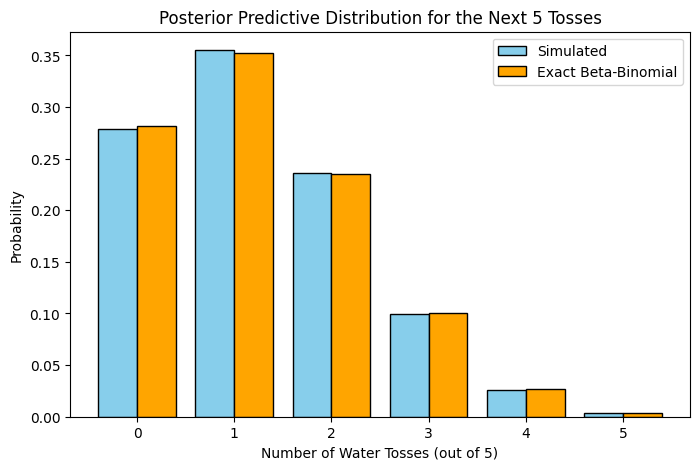

In [3]:
# Exact Beta-Binomial probabilities
from scipy.special import betaln, binom

alpha_post = 1 + W
beta_post = 1 + L
n_pred = 5

def beta_binomial_pmf(k, n, a, b):
    # PMF of beta-binomial
    return binom(n, k) * np.exp(betaln(k + a, n - k + b) - betaln(a, b))

exact_probs = [beta_binomial_pmf(k, n_pred, alpha_post, beta_post) for k in range(n_pred + 1)]

print("Number of water tosses | Exact Probability")
print("-" * 45)
for k, p in enumerate(exact_probs):
    print(f"{k:<22} | {p:.4f}")

# Plot comparing simulated and exact
plt.figure(figsize=(8, 5))
plt.bar(np.arange(n_pred + 1) - 0.2, w_counts / np.sum(w_counts), width=0.4, color="skyblue", edgecolor="black", label="Simulated")
plt.bar(np.arange(n_pred + 1) + 0.2, exact_probs, width=0.4, color="orange", edgecolor="black", label="Exact Beta-Binomial")
plt.title("Posterior Predictive Distribution for the Next 5 Tosses")
plt.xlabel("Number of Water Tosses (out of 5)")
plt.ylabel("Probability")
plt.xticks(range(next_tosses + 1))
plt.legend()
plt.show()